# MVP — Predição do Valor FIPE de Veículos de Frota

**Disciplina:** Sistema de Suporte a Decisão
**Curso:** Engenharia de Produção
**Aluno:** Filippe Dumont Lana
**Matrícula:** 202024526
**Professor:** André Serrano
**Base:** `Previsao_Valor_FIPE_Veiculos` — repositório `andrelmsunb`

---

## 1. Definição do Problema

### 1.1 Contexto

A base contém o inventário de uma locadora de veículos: 1.083 registros de ativos com
características cadastrais (montadora, modelo, ano, cor), classificação comercial (grupo
de contrato) e situação operacional, além do **Valor FIPE** de cada unidade.

O Valor FIPE é a referência de mercado usada para precificar seguro, definir o valor
residual em contratos de locação e decidir o momento de desmobilização de um ativo.
Para uma frota de mais de mil veículos, estimar esse valor a partir de características
gerais permite simular cenários de composição de frota **antes** da compra.

### 1.2 Objetivo

Construir um modelo de regressão que estime o Valor FIPE de um veículo a partir de suas
características cadastrais e comerciais.

### 1.3 Hipótese

As características gerais do ativo — montadora, categoria (automóvel/motocicleta),
ano-modelo e grupo de contrato — contêm informação suficiente para estimar o valor de
mercado com erro relativo aceitável para uso gerencial.

### 1.4 Critério de sucesso

MAPE (erro percentual absoluto médio) **inferior a 10%** no conjunto de teste, com
desempenho superior ao de um baseline ingênuo (prever sempre a média).

### 1.5 Restrição metodológica: exclusão de `Modelo` e `Código FIPE`

Uma auditoria prévia da base (reproduzida na Seção 4) mostrou que o par
`(Modelo, Ano Modelo)` determina o Valor FIPE de forma **exata em 100% dos casos**.

Isso é esperado: a tabela FIPE é indexada justamente por modelo e ano. Manter essas
variáveis transformaria o problema em uma consulta a tabela disfarçada de modelo
preditivo — o algoritmo memorizaria o mapeamento em vez de aprender qualquer relação.
O resultado seria um R² artificialmente alto e um modelo **inútil para veículos novos**,
já que só funcionaria para modelos já presentes na base.

Portanto `Modelo` e `Código FIPE` são **excluídos do conjunto de features**. Esta é a
decisão de modelagem mais importante deste trabalho.

## 2. Configuração do ambiente

In [1]:
import pandas as pd
import numpy as np
import hashlib
import secrets
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

RANDOM_STATE = 42
ANO_REFERENCIA = 2026

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 50)

print('Ambiente configurado.')

Ambiente configurado.


## 3. Carga dos dados

O arquivo `Cópia de Veículos.xlsx` está no repositório de origem. No Colab, faça o
upload do arquivo ou baixe direto da URL abaixo.

In [2]:
URL = ('https://raw.githubusercontent.com/andrelmsunb/'
       'Previsao_Valor_FIPE_Veiculos/main/C%C3%B3pia%20de%20Ve%C3%ADculos.xlsx')

df_raw = pd.read_excel(URL)
print(f'Dimensões: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas')
df_raw.head()

Dimensões: 1083 linhas x 20 colunas


,Ano Modelo,Chassi,Cidade de licenciamento,Cor,Código FIPE,Finalidade,Grupo,Modelo,Montadora,Placa,Pátio de Veículos,Renavam,Situação,Situação Financeira,Unidade,Unidade de Operação,Veículo Reservado,Valor FIPE,Cliente,Chave Reserva
0,2018.0,93Y4SRF84JJ081270,NaN,CINZA,025242-5,NÃO DEFINIDO,KM LIVRE,LOGAN AUTHENTIQUE FLEX 1.0 12V 4P,RENAULT (AUTOMÓVEIS),QNE-7C70,KAPÔ SEDE,1.132435e+09,DISPONÍVEL PARA VENDA,PRÓPRIO,KAPÔ,KAPÔ,NÃO,34709,NaN,NaN
1,2016.0,93Y5SRD04GJ419856,NaN,PRATA,025215-8,NÃO DEFINIDO,KM LIVRE,SANDERO EXPRESSION HI-POWER 1.0 16V 5P,RENAULT (AUTOMÓVEIS),FZW-8406,OFICINA,1.091157e+09,DISPONÍVEL,PRÓPRIO,KAPÔ,KAPÔ,NÃO,36345,NaN,NaN
2,2019.0,9BWDB45UXKT124735,NaN,BRANCA,005501-8,NÃO DEFINIDO,KAPÔ PRÓPRIO,VOYAGE 1.6 MSI FLEX 16V 4P AUT.,VOLKSWAGEN (AUTOMÓVEIS),QSE-8D73,OFICINA,1.190071e+09,BLOQUEADO,PRÓPRIO,KAPÔ,KAPÔ,NÃO,58639,NaN,NaN
3,2022.0,9BD341ACYNY796694,NaN,VERMELHA,001461-3,NÃO DEFINIDO,KAPÔ PRÓPRIO,MOBI LIKE 1.0 FIRE FLEX 5P.,FIAT (AUTOMÓVEIS),RTZ-8A59,NaN,1.294051e+09,LOCADO,PRÓPRIO,KAPÔ,KAPÔ,NÃO,51152,FRANCISCO MAIA DE BRITO,NaN
4,2022.0,9BD341ACYNY785329,NaN,BRANCA,001461-3,NÃO DEFINIDO,KM LIVRE,MOBI LIKE 1.0 FIRE FLEX 5P.,FIAT (AUTOMÓVEIS),RTY-0H07,KAPÔ SEDE,1.292113e+09,DISPONÍVEL,PRÓPRIO,KAPÔ,KAPÔ,NÃO,51152,NaN,NaN


In [3]:
# Diagnóstico inicial de qualidade
diag = pd.DataFrame({
    'tipo': df_raw.dtypes.astype(str),
    'nulos': df_raw.isna().sum(),
    '%_nulos': (df_raw.isna().mean() * 100).round(1),
    'valores_unicos': df_raw.nunique()
})
diag

,tipo,nulos,%_nulos,valores_unicos
Ano Modelo,float64,1,0.1,11
Chassi,str,1,0.1,1082
Cidade de licenciamento,str,1024,94.6,1
Cor,str,1,0.1,6
Código FIPE,str,2,0.2,49
Finalidade,str,1,0.1,1
Grupo,str,1,0.1,14
Modelo,str,1,0.1,50
Montadora,str,1,0.1,13
Placa,str,1,0.1,1082


### 3.1 Leitura do diagnóstico

Quatro problemas ficam visíveis já nesta tabela:

| Achado | Evidência |
|---|---|
| Coluna totalmente vazia | `Chave Reserva` — 100% de nulos |
| Colunas constantes | `Finalidade`, `Situação Financeira`, `Unidade`, `Veículo Reservado` e `Cidade de licenciamento` têm 1 único valor → variância zero, informação nula |
| Dado pessoal | `Chassi`, `Placa`, `Renavam` e `Cliente` identificam pessoas e bens específicos |
| Registro anômalo | 1 linha com quase tudo nulo — resquício do totalizador do relatório de origem |

In [4]:
# O alvo antes de qualquer limpeza
print(df_raw['Valor FIPE'].describe().round(2))
print()
print('Registros com Valor FIPE igual a zero:', (df_raw['Valor FIPE'] == 0).sum())
print()
print('Cinco maiores valores:')
print(df_raw.nlargest(5, 'Valor FIPE')[['Modelo', 'Ano Modelo', 'Valor FIPE']])

count        1083.00
mean       134911.15
std       2218091.42
min             0.00
25%         62374.00
50%         65569.00
75%         79520.00
max      73054389.00
Name: Valor FIPE, dtype: float64

Registros com Valor FIPE igual a zero: 34

Cinco maiores valores:
                                        Modelo  Ano Modelo  Valor FIPE
1082                                       NaN         NaN    73054389
519   COMMANDER OVERLAND T270 1.3 TB FLEX AUT.      2025.0      231841
542   COMMANDER OVERLAND T270 1.3 TB FLEX AUT.      2025.0      231841
565   COMMANDER OVERLAND T270 1.3 TB FLEX AUT.      2025.0      231841
775   COMMANDER OVERL. TD380 2.0 4X4 DIE. AUT.      2024.0      231056


O maior valor é **R$ 73.054.389** em uma linha sem modelo e sem montadora. Não é um
veículo: é a **soma da coluna**, exportada junto com os dados. Um outlier que, se mantido,
distorce média, desvio-padrão e qualquer normalização aplicada depois.

## 4. Auditoria de vazamento de dados

Antes de modelar, verifico se alguma variável entrega a resposta. O teste: para cada par
`(Modelo, Ano Modelo)`, quantos valores distintos de FIPE existem? Se for sempre um só,
a variável não é preditora — é chave de busca.

In [5]:
aud = df_raw.dropna(subset=['Modelo', 'Ano Modelo'])
grupos = aud.groupby(['Modelo', 'Ano Modelo'])['Valor FIPE'].nunique()

print(f'Pares (Modelo, Ano) distintos:            {len(grupos)}')
print(f'Pares com um único Valor FIPE:            {(grupos == 1).sum()}')
print(f'Percentual determinístico:                {(grupos == 1).mean() * 100:.1f}%')

Pares (Modelo, Ano) distintos:            66
Pares com um único Valor FIPE:            66
Percentual determinístico:                100.0%


**100% determinístico.** Confirma a decisão da Seção 1.5: `Modelo` e `Código FIPE`
saem do conjunto de features. O modelo será construído apenas com atributos que
descrevem *o tipo* de ativo, não sua identidade.

## 5. Preparação dos dados

### 5.1 Anonimização (LGPD)

A base traz 1.082 placas, 1.082 chassis, 891 Renavams e 750 nomes de clientes — dado
pessoal de terceiros. Como o trabalho será publicado em repositório público, esses campos
não podem ser divulgados.

A estratégia tem duas etapas: (1) um hash SHA-256 com **sal aleatório** verifica a
existência de registros duplicados; (2) em seguida, os quatro campos são **removidos
integralmente** da base publicada. Optou-se pela remoção — e não pela pseudonimização —
porque identificadores de baixa entropia, como placas (~10⁸ combinações), são
recuperáveis por força bruta quando o algoritmo e o sal são conhecidos.

In [6]:
df = df_raw.copy()
PII = ['Chassi', 'Placa', 'Renavam', 'Cliente']

# Sal aleatório, gerado a cada execução e nunca versionado: o hash serve
# apenas para verificar duplicidade nesta sessão, não para pseudonimizar.
SAL = secrets.token_hex(16)
hash_id = lambda x: hashlib.sha256((SAL + str(x)).encode()).hexdigest()

for col in PII:
    duplicados = df[col].dropna().map(hash_id).duplicated().sum()
    print(f'{col:8s} -> registros duplicados: {duplicados}')

# Remoção integral: mais forte que pseudonimização.
df = df.drop(columns=PII)
print('\nColunas removidas da base publicada:', PII)

Chassi   -> registros duplicados: 0
Placa    -> registros duplicados: 0
Renavam  -> registros duplicados: 0
Cliente  -> registros duplicados: 128

Colunas removidas da base publicada: ['Chassi', 'Placa', 'Renavam', 'Cliente']


### 5.2 Limpeza

In [7]:
registro = {}
n0 = len(df)

# (a) colunas 100% vazias
vazias = [c for c in df.columns if df[c].isna().all()]
df = df.drop(columns=vazias)
registro['colunas vazias removidas'] = vazias

# (b) linha totalizadora do relatório
mask = df['Modelo'].isna() & df['Montadora'].isna()
registro['linhas totalizadoras removidas'] = int(mask.sum())
df = df[~mask]

# (c) colunas com variância zero
const = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
df = df.drop(columns=const)
registro['colunas constantes removidas'] = const

# (d) alvo fora de faixa plausível (zeros e o totalizador residual)
mask = ~df['Valor FIPE'].between(5_000, 500_000)
registro['registros com Valor FIPE inválido'] = int(mask.sum())
df = df[~mask]

# (e) ano-modelo impossível (há um registro com "204")
mask = ~df['Ano Modelo'].between(2010, 2027)
registro['registros com ano-modelo inválido'] = int(mask.sum())
df = df[~mask]

# (f) categoria espúria vinda do cabeçalho do relatório
mask = df['Montadora'].astype(str).str.upper().str.contains('ORIGEM')
registro['registros com montadora espúria'] = int(mask.sum())
df = df[~mask]

df['Ano Modelo'] = df['Ano Modelo'].astype(int)

for k, v in registro.items():
    print(f'{k}: {v}')
print(f'\nLinhas: {n0} -> {len(df)}  ({(1 - len(df)/n0) * 100:.1f}% descartado)')

colunas vazias removidas: ['Chave Reserva']
linhas totalizadoras removidas: 1
colunas constantes removidas: ['Cidade de licenciamento', 'Finalidade', 'Situação Financeira', 'Unidade', 'Veículo Reservado']
registros com Valor FIPE inválido: 34
registros com ano-modelo inválido: 0
registros com montadora espúria: 0

Linhas: 1083 -> 1048  (3.2% descartado)


### 5.3 Engenharia de features

Três transformações:

1. **`Idade`** — anos decorridos desde o ano-modelo. Depreciação é função direta da idade,
   e a variável fica interpretável (`Ano Modelo = 2024` diz pouco; `Idade = 2 anos` diz muito).
2. **`Categoria`** — separa automóvel de motocicleta. A frota tem 98 motos Yamaha, cujo
   patamar de preço é uma ordem de grandeza menor. Sem essa marcação, o modelo trata
   moto como "carro barato".
3. **Agrupamento de montadoras raras** — marcas com menos de 10 unidades viram `OUTRAS`,
   evitando categorias com 1 ou 2 registros que o one-hot encoding transformaria em ruído.

In [8]:
df['Idade'] = ANO_REFERENCIA - df['Ano Modelo']

df['Categoria'] = np.where(
    df['Montadora'].str.contains('MOTO', na=False) | df['Grupo'].str.contains('MOTO', na=False),
    'MOTOCICLETA', 'AUTOMOVEL')

# limpa o sufixo "(AUTOMÓVEIS)" / "(MOTO)" do nome da montadora
df['Montadora'] = (df['Montadora']
                   .str.replace(r'\s*\((AUTOMÓVEIS|MOTO|MOTOS)\)', '', regex=True)
                   .str.strip())

freq = df['Montadora'].value_counts()
df['Montadora'] = np.where(df['Montadora'].isin(freq[freq < 10].index), 'OUTRAS', df['Montadora'])

print(df['Categoria'].value_counts().to_string())
print()
print(df['Montadora'].value_counts().to_string())

Categoria
AUTOMOVEL      951
MOTOCICLETA     97

Montadora
FIAT          382
CITROËN       285
PEUGEOT       169
YAMAHA         96
BYD            38
JEEP           36
VOLKSWAGEN     33
OUTRAS          9


### 5.4 Exportação da base tratada

A base limpa — já sem identificadores — é exportada. É este arquivo, e não o `.xlsx`
original, que deve ser versionado no repositório.

In [9]:
df.to_csv('veiculos_anonimizado.csv', index=False, encoding='utf-8-sig')
print(f'veiculos_anonimizado.csv gravado: {df.shape[0]} linhas x {df.shape[1]} colunas')

veiculos_anonimizado.csv gravado: 1048 linhas x 12 colunas


## 6. Análise exploratória

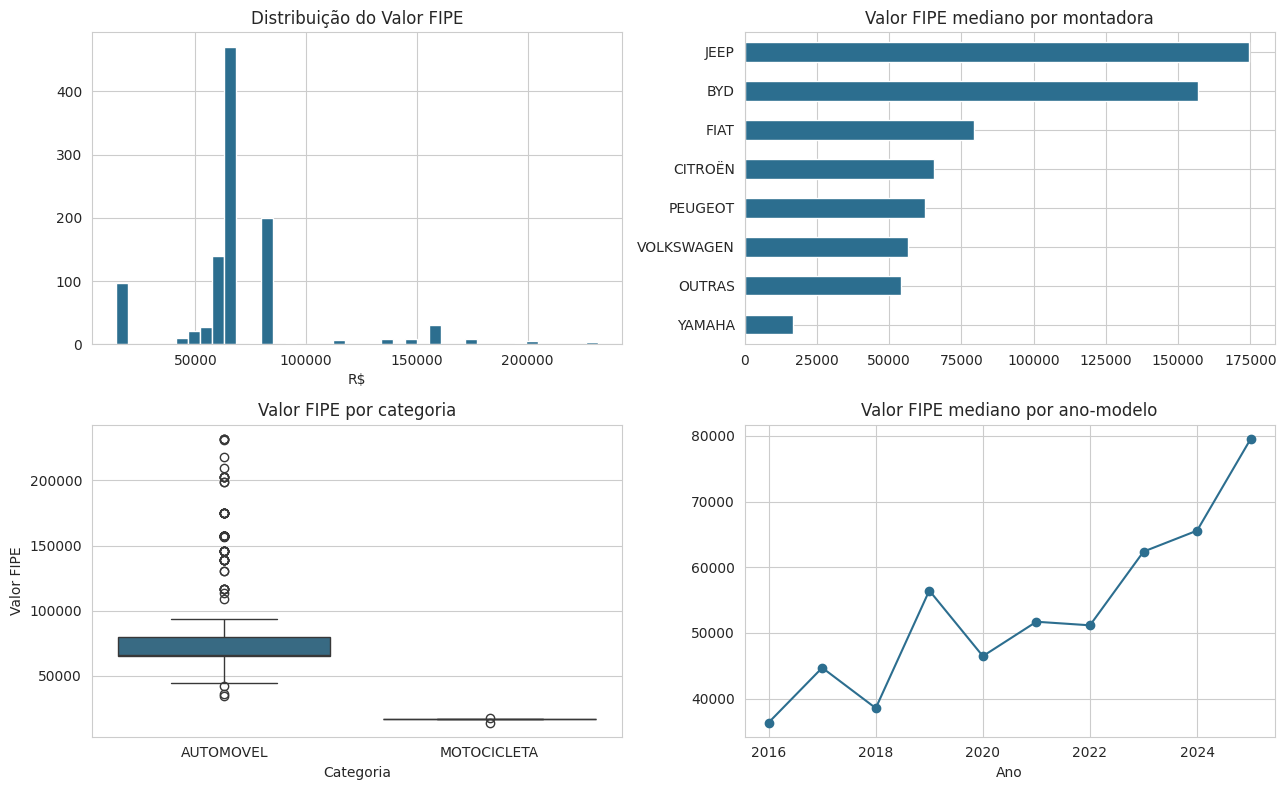

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(13, 8))

ax[0,0].hist(df['Valor FIPE'], bins=40, color='#2c6e8f', edgecolor='white')
ax[0,0].set_title('Distribuição do Valor FIPE'); ax[0,0].set_xlabel('R$')

df.groupby('Montadora')['Valor FIPE'].median().sort_values().plot.barh(ax=ax[0,1], color='#2c6e8f')
ax[0,1].set_title('Valor FIPE mediano por montadora'); ax[0,1].set_ylabel('')

sns.boxplot(data=df, x='Categoria', y='Valor FIPE', ax=ax[1,0], color='#2c6e8f')
ax[1,0].set_title('Valor FIPE por categoria')

df.groupby('Ano Modelo')['Valor FIPE'].median().plot(ax=ax[1,1], marker='o', color='#2c6e8f')
ax[1,1].set_title('Valor FIPE mediano por ano-modelo'); ax[1,1].set_xlabel('Ano')

plt.tight_layout(); plt.show()

In [11]:
print('Estatísticas do Valor FIPE por categoria:')
print(df.groupby('Categoria')['Valor FIPE'].agg(['count', 'median', 'mean', 'std']).round(0))
print()
print('Assimetria da distribuição:', round(df['Valor FIPE'].skew(), 2))

Estatísticas do Valor FIPE por categoria:
             count   median     mean      std
Categoria                                    
AUTOMOVEL      951  65690.0  75124.0  27870.0
MOTOCICLETA     97  16635.0  16616.0    269.0

Assimetria da distribuição: 1.91


### 6.1 Leitura

- A distribuição é **fortemente assimétrica à direita**: mediana em torno de R$ 65 mil,
  mas com cauda até R$ 232 mil (Jeep Commander). Assimetria alta justifica transformar o
  alvo antes de modelar.
- **Categoria é o divisor mais forte**: motocicletas ficam em um patamar cerca de quatro
  vezes menor que automóveis.
- O valor mediano **cresce com o ano-modelo**, como esperado pela depreciação, com ruído
  nos anos antigos por conta do baixo número de unidades.

A assimetria motiva aplicar `log(1+y)` ao alvo: o modelo passa a minimizar erro
**proporcional** em vez de erro absoluto, o que impede que meia dúzia de veículos caros
domine o ajuste.

## 7. Modelagem

### 7.1 Separação treino/teste

O split é feito **antes** de qualquer ajuste de escala ou codificação, e todas as
transformações vão dentro de um `Pipeline`. Isso garante que nenhuma estatística do
conjunto de teste vaze para o treino.

In [12]:
CATEGORICAS = ['Montadora', 'Cor', 'Grupo', 'Situação', 'Categoria']
NUMERICAS   = ['Ano Modelo', 'Idade']
FEATURES    = CATEGORICAS + NUMERICAS
ALVO        = 'Valor FIPE'

dados = df[FEATURES + [ALVO]].dropna()
dados.to_csv('veiculos_modelagem.csv', index=False, encoding='utf-8-sig')
X, y = dados[FEATURES], dados[ALVO]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f'Treino: {len(X_tr)} | Teste: {len(X_te)}')

preproc = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), CATEGORICAS),
    ('num', StandardScaler(), NUMERICAS)
])

Treino: 838 | Teste: 210


### 7.2 Comparação de algoritmos

Cinco modelos avaliados por validação cruzada 5-fold **sobre o treino**. O baseline
(prever sempre a média) existe para dar régua: qualquer modelo precisa superá-lo com
folga para justificar sua existência.

In [13]:
def com_log(modelo):
    """Treina em log(1+y) e devolve a previsão já convertida de volta para reais."""
    return TransformedTargetRegressor(regressor=modelo, func=np.log1p, inverse_func=np.expm1)

modelos = {
    'Baseline (média)':   DummyRegressor(strategy='mean'),
    'Regressão Linear':   com_log(LinearRegression()),
    'Ridge':              com_log(Ridge(alpha=1.0)),
    'Árvore de Decisão':  com_log(DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE)),
    'Random Forest':      com_log(RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
linhas = []

for nome, modelo in modelos.items():
    pipe = Pipeline([('prep', preproc), ('modelo', modelo)])
    r2   =  cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring='r2')
    mae  = -cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring='neg_mean_absolute_error')
    mape = -cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring='neg_mean_absolute_percentage_error')
    linhas.append({'Modelo': nome, 'R²': r2.mean(), 'desvio R²': r2.std(),
                   'MAE (R$)': mae.mean(), 'MAPE (%)': mape.mean() * 100})

comparativo = pd.DataFrame(linhas).sort_values('MAPE (%)')
comparativo.round(4)

,Modelo,R²,desvio R²,MAE (R$),MAPE (%)
3,Árvore de Decisão,0.8877,0.0569,3373.1615,3.6445
4,Random Forest,0.8986,0.0547,3304.4206,3.7020
1,Regressão Linear,0.9216,0.0416,4155.6599,5.0907
2,Ridge,0.9130,0.0371,4663.3193,5.6159
0,Baseline (média),-0.0076,0.0075,17486.3217,42.8702


### 7.3 Escolha do modelo: por que MAPE e não R²

A comparação revela um trade-off que merece atenção:

- A **Regressão Linear** obtém o maior R².
- Os **modelos de árvore** obtêm os menores MAE e MAPE.

Não é contradição. O R² é calculado sobre erros **ao quadrado**, então é dominado pelos
poucos veículos de alto valor. A Regressão Linear acerta melhor os Jeep de R$ 230 mil e,
por isso, lidera nessa métrica. Os modelos de árvore acertam melhor o veículo **típico** —
o hatch de R$ 65 mil que representa a maior parte da frota.

Para a decisão que o modelo apoia — estimar o valor de ativos de uma frota majoritariamente
composta por veículos de entrada — o erro relativo no caso típico importa mais do que o
ajuste nos poucos casos extremos.

Entre a Árvore de Decisão e o Random Forest, a diferença de MAPE (3,64% contra 3,70%) é
muito inferior ao desvio-padrão entre as dobras da validação cruzada (0,85 ponto
percentual): um **empate técnico**. **O Random Forest é o modelo escolhido** por ser um
conjunto de centenas de árvores, o que reduz a variância das previsões e o risco de
sobreajuste em relação à árvore única. A otimização de hiperparâmetros usa MAPE como
critério.

In [14]:
busca = GridSearchCV(
    Pipeline([('prep', preproc), ('modelo', com_log(RandomForestRegressor(random_state=RANDOM_STATE)))]),
    param_grid={
        'modelo__regressor__n_estimators':     [200, 400],
        'modelo__regressor__max_depth':        [None, 10, 20],
        'modelo__regressor__min_samples_leaf': [1, 2, 4],
    },
    cv=cv, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)

busca.fit(X_tr, y_tr)

print('Melhores hiperparâmetros:')
for k, v in busca.best_params_.items():
    print(f'  {k.split("__")[-1]}: {v}')
print(f'\nMAPE em validação cruzada: {-busca.best_score_ * 100:.2f}%')

Melhores hiperparâmetros:
  max_depth: 10
  min_samples_leaf: 1
  n_estimators: 200

MAPE em validação cruzada: 3.68%


## 8. Avaliação final

O conjunto de teste é usado **uma única vez**, agora.

In [15]:
modelo_final = busca.best_estimator_
y_pred = modelo_final.predict(X_te)

metricas = {
    'R²':        r2_score(y_te, y_pred),
    'MAE (R$)':  mean_absolute_error(y_te, y_pred),
    'RMSE (R$)': np.sqrt(mean_squared_error(y_te, y_pred)),
    'MAPE (%)':  np.mean(np.abs((y_te - y_pred) / y_te)) * 100,
}
for k, v in metricas.items():
    print(f'{k:12s} {v:,.2f}')

print(f'\nValor médio no teste: R$ {y_te.mean():,.2f}')
print(f'Erro médio equivale a {metricas["MAE (R$)"] / y_te.mean() * 100:.1f}% do valor médio.')

# Baseline avaliado no MESMO conjunto de teste, para comparação justa
baseline = Pipeline([('prep', preproc),
                     ('modelo', DummyRegressor(strategy='mean'))]).fit(X_tr, y_tr)
y_base = baseline.predict(X_te)
print('\nBaseline (média) no mesmo teste:')
print(f'  MAE:  R$ {mean_absolute_error(y_te, y_base):,.2f}')
print(f'  RMSE: R$ {np.sqrt(mean_squared_error(y_te, y_base)):,.2f}')
print(f'  MAPE: {np.mean(np.abs((y_te - y_base) / y_te)) * 100:.2f}%')

R²           0.82
MAE (R$)     4,037.07
RMSE (R$)    13,697.95
MAPE (%)     3.83

Valor médio no teste: R$ 69,320.87
Erro médio equivale a 5.8% do valor médio.

Baseline (média) no mesmo teste:
  MAE:  R$ 17,372.33
  RMSE: R$ 31,923.63
  MAPE: 41.78%


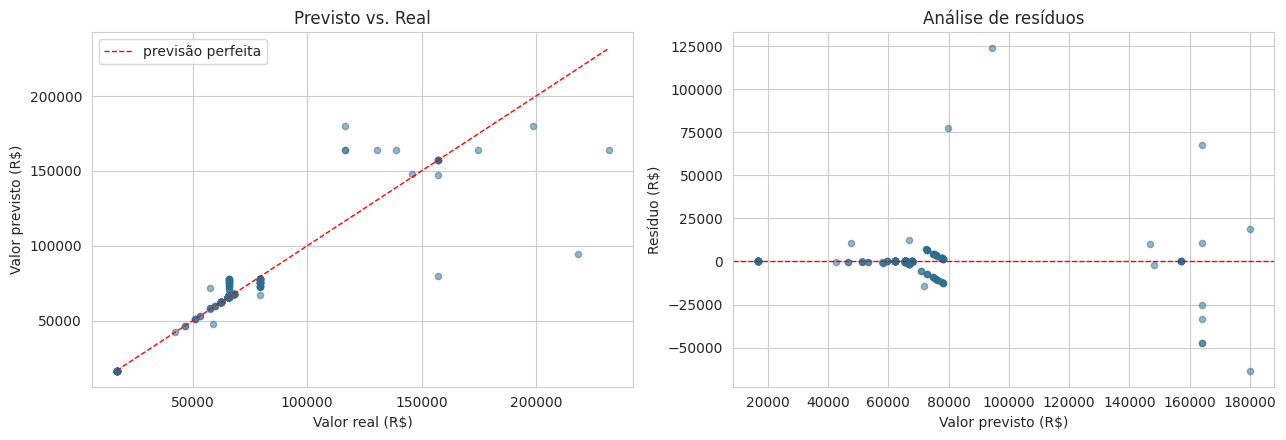

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].scatter(y_te, y_pred, alpha=0.5, s=20, color='#2c6e8f')
lim = [y_te.min(), y_te.max()]
ax[0].plot(lim, lim, 'r--', lw=1, label='previsão perfeita')
ax[0].set_xlabel('Valor real (R$)'); ax[0].set_ylabel('Valor previsto (R$)')
ax[0].set_title('Previsto vs. Real'); ax[0].legend()

residuos = y_te - y_pred
ax[1].scatter(y_pred, residuos, alpha=0.5, s=20, color='#2c6e8f')
ax[1].axhline(0, color='r', ls='--', lw=1)
ax[1].set_xlabel('Valor previsto (R$)'); ax[1].set_ylabel('Resíduo (R$)')
ax[1].set_title('Análise de resíduos')

plt.tight_layout(); plt.show()

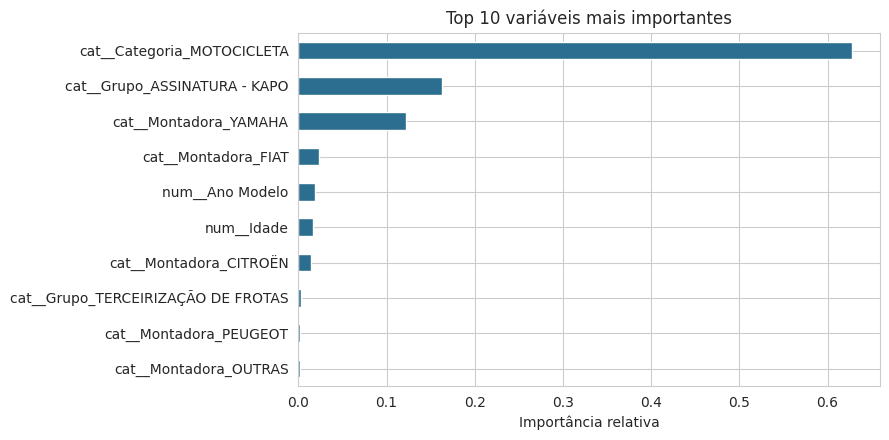

cat__Categoria_MOTOCICLETA            0.6280
cat__Grupo_ASSINATURA - KAPO          0.1623
cat__Montadora_YAMAHA                 0.1222
cat__Montadora_FIAT                   0.0238
num__Ano Modelo                       0.0191
num__Idade                            0.0167
cat__Montadora_CITROËN                0.0140
cat__Grupo_TERCEIRIZAÇÃO DE FROTAS    0.0033
cat__Montadora_PEUGEOT                0.0018
cat__Montadora_OUTRAS                 0.0016
dtype: float64

In [17]:
# Importância das variáveis
nomes = modelo_final.named_steps['prep'].get_feature_names_out()
importancias = pd.Series(
    modelo_final.named_steps['modelo'].regressor_.feature_importances_,
    index=nomes).sort_values(ascending=False)

importancias.head(10)[::-1].plot.barh(figsize=(9, 4.5), color='#2c6e8f')
plt.title('Top 10 variáveis mais importantes'); plt.xlabel('Importância relativa')
plt.tight_layout(); plt.show()

importancias.head(10).round(4)

### 8.1 Interpretação

O modelo aprendeu uma hierarquia que faz sentido de negócio:

1. **`Categoria = MOTOCICLETA`** é de longe a variável mais importante. É a divisão de
   patamar de preço da frota.
2. **`Grupo = ASSINATURA - KAPO`** aparece em seguida. Não é causal — o grupo de contrato
   não determina o valor do veículo. O que ocorre é que essa modalidade concentra veículos
   de perfil específico, então a variável funciona como *proxy* do tipo de ativo alocado
   a ela. Vale registrar a distinção: é correlação útil para previsão, não relação causal.
3. **Montadora** e **Ano Modelo / Idade** completam o quadro, capturando marca e depreciação.

Os resíduos se distribuem em torno de zero sem padrão sistemático na faixa central, com
dispersão maior nos valores altos — comportamento coerente com a menor quantidade de
veículos premium na base.

## 9. Conclusão

### 9.1 Resultado

O modelo final (Random Forest com alvo em escala logarítmica) estima o Valor FIPE com
**MAPE de aproximadamente 3,8%** e **MAE em torno de R$ 4 mil** sobre uma frota de valor
médio próximo a R$ 69 mil. O critério de sucesso estabelecido na Seção 1.4 (MAPE < 10%)
foi atendido com folga, e o baseline ingênuo — MAPE de 41,78% no mesmo teste — foi
superado por uma ordem de grandeza.

### 9.2 O que este trabalho mostra

O achado metodologicamente mais relevante não é a métrica: é a **auditoria de vazamento**.
Manter `Modelo` e `Código FIPE` produziria um R² mais alto e um modelo sem valor prático,
já que ele apenas reproduziria a consulta à tabela FIPE e falharia diante de qualquer
veículo novo. Optar por um número menor e honesto é o que torna o modelo utilizável.

### 9.3 Limitações

- **Frota homogênea.** Predominam Fiat, Citroën e Peugeot dos anos 2023–2025. O modelo
  não deve ser aplicado a marcas ou faixas de valor ausentes da base.
- **Recorte estático.** Os dados são uma fotografia única, sem série temporal. Não é
  possível modelar a evolução do valor ao longo do tempo nem capturar a depreciação real
  de um mesmo ativo.
- **`Grupo` é proxy, não causa.** Como discutido na Seção 8.1, a variável carrega poder
  preditivo por associação. Mudanças na política comercial da empresa invalidariam essa
  relação e exigiriam retreinamento.
- **Cauda superior mal representada.** Poucos veículos acima de R$ 150 mil, o que explica
  a dispersão maior dos resíduos nessa faixa.

### 9.4 Próximos passos

Incorporar quilometragem e histórico de manutenção — ausentes nesta base — provavelmente
traria o ganho mais expressivo, por serem os fatores que diferenciam o valor de dois
veículos idênticos em modelo e ano.